# House Rent Price Prediction

<img src='https://static.vecteezy.com/system/resources/thumbnails/070/213/792/small/keychain-in-the-shape-of-a-house-with-the-word-rent-hanging-in-front-of-a-cozy-house-with-a-veranda-concept-of-home-rental-temporary-housing-real-estate-market-photo.jpg'>

🇹🇷 Türkçe
Bu projenin amacı, farklı makine öğrenmesi ve derin öğrenme algoritmalarını kullanarak ev kira fiyatlarını tahmin etmektir.

🇬🇧 English
The goal of this project is to predict home rental prices using different machine learning and deep learning algorithms.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense

In [2]:
df=pd.read_csv('House_Rent_Dataset.csv')

In [3]:
#EDA

In [4]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
df.tail()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent
4745,2022-05-04,2,15000,1000,4 out of 5,Carpet Area,Suchitra Circle,Hyderabad,Unfurnished,Bachelors,2,Contact Owner


In [6]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [7]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


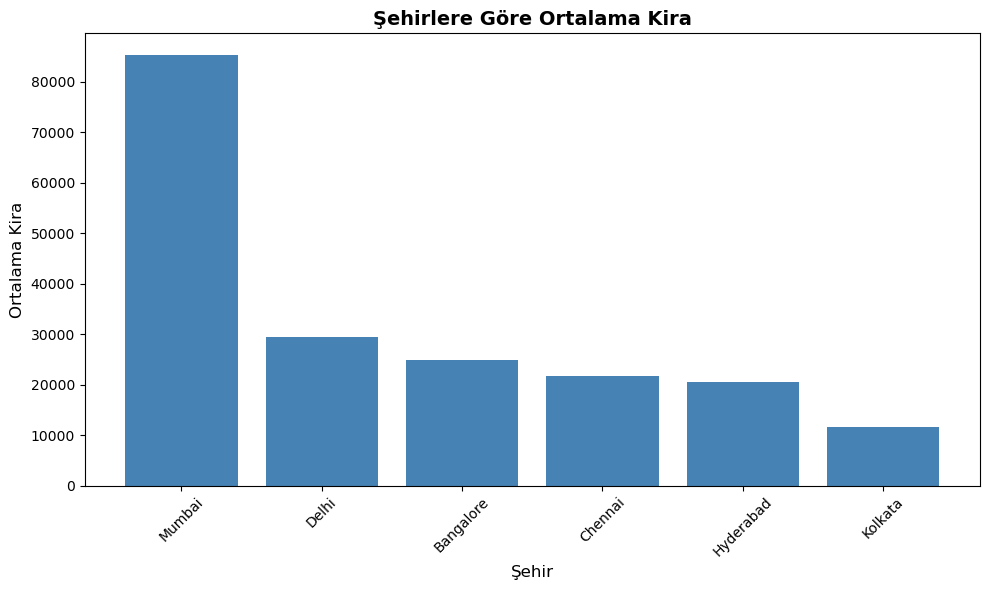

In [8]:
# Şehirlere göre ortalama kira dağılımı
plt.figure(figsize=(10, 6))
city_rent = df.groupby('City')['Rent'].mean().sort_values(ascending=False)
plt.bar(city_rent.index, city_rent.values, color='steelblue')
plt.title('Şehirlere Göre Ortalama Kira', fontsize=14, fontweight='bold')
plt.xlabel('Şehir', fontsize=12)
plt.ylabel('Ortalama Kira', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

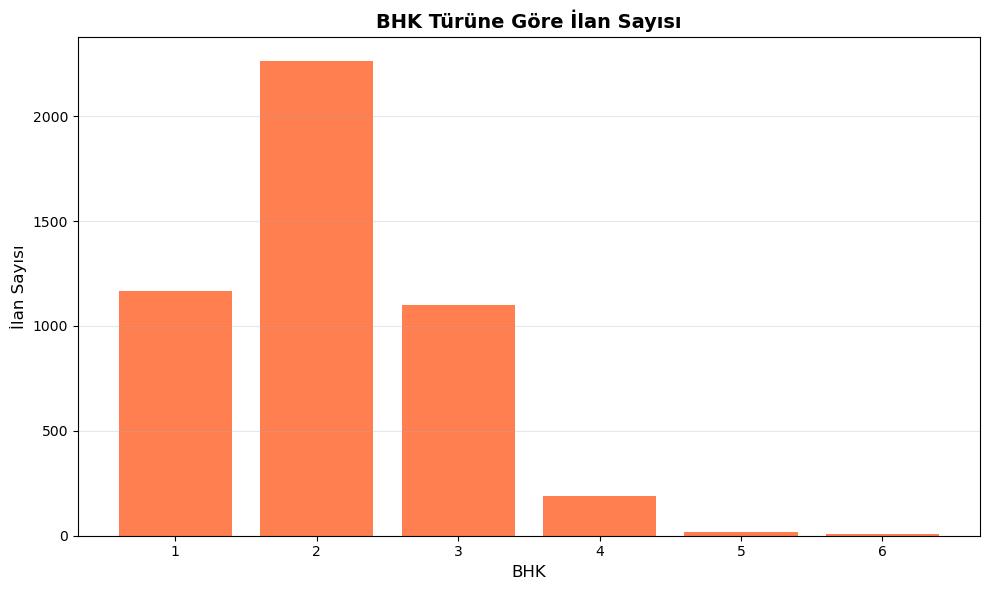

In [9]:
# BHK türüne göre ilan sayısı
plt.figure(figsize=(10, 6))
bhk_count = df['BHK'].value_counts().sort_index()
plt.bar(bhk_count.index, bhk_count.values, color='coral')
plt.title('BHK Türüne Göre İlan Sayısı', fontsize=14, fontweight='bold')
plt.xlabel('BHK', fontsize=12)
plt.ylabel('İlan Sayısı', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

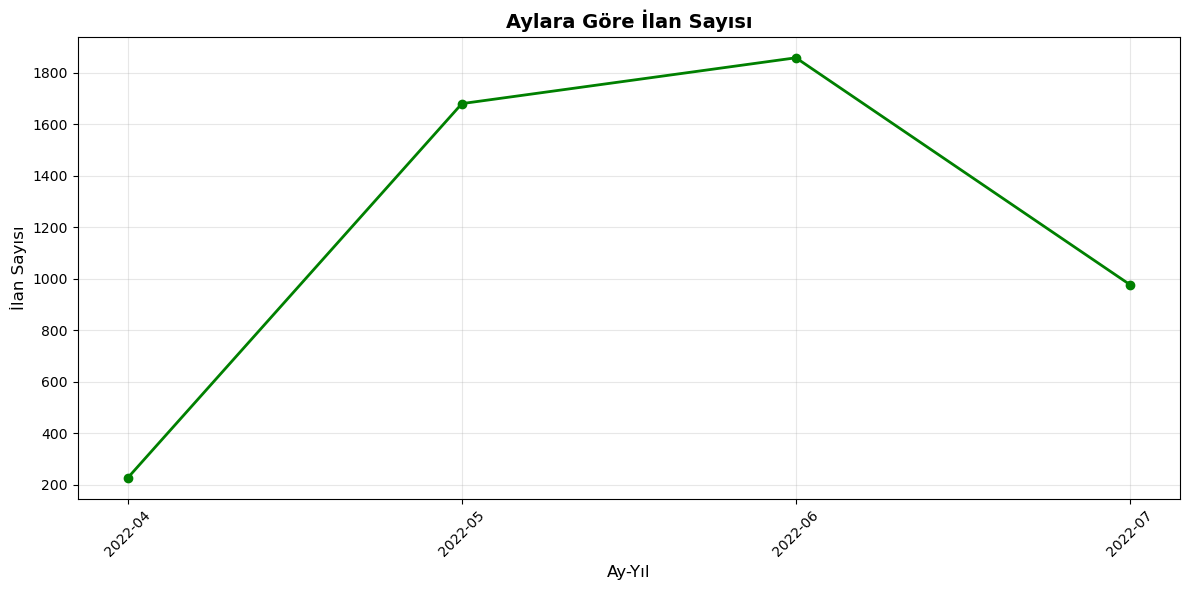

In [10]:
# Dönemsel ilanlar (Ay-Yıl)
plt.figure(figsize=(12, 6))
df['Posted On'] = pd.to_datetime(df['Posted On'])
monthly_posts = df.groupby(df['Posted On'].dt.to_period('M')).size()
plt.plot(monthly_posts.index.astype(str), monthly_posts.values, marker='o', linewidth=2, color='green')
plt.title('Aylara Göre İlan Sayısı', fontsize=14, fontweight='bold')
plt.xlabel('Ay-Yıl', fontsize=12)
plt.ylabel('İlan Sayısı', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

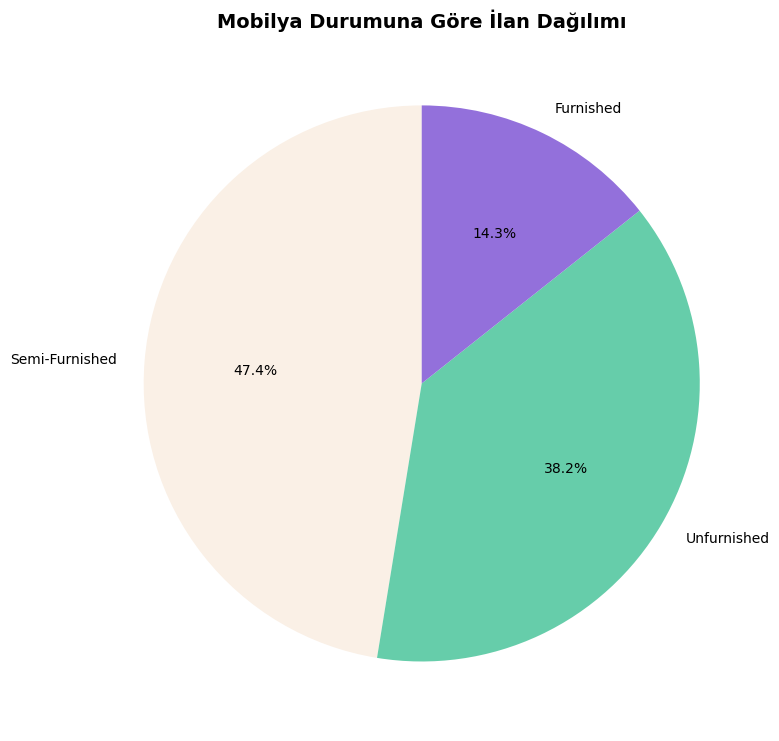

In [11]:
# Mobilya durumuna göre dağılım (Pasta Grafiği)
plt.figure(figsize=(8, 8))
furnishing_count = df['Furnishing Status'].value_counts()
plt.pie(furnishing_count.values, labels=furnishing_count.index, autopct='%1.1f%%', 
        colors=['#FAF0E6', '#66CDAA', '#9370DB'], startangle=90)
plt.title('Mobilya Durumuna Göre İlan Dağılımı', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

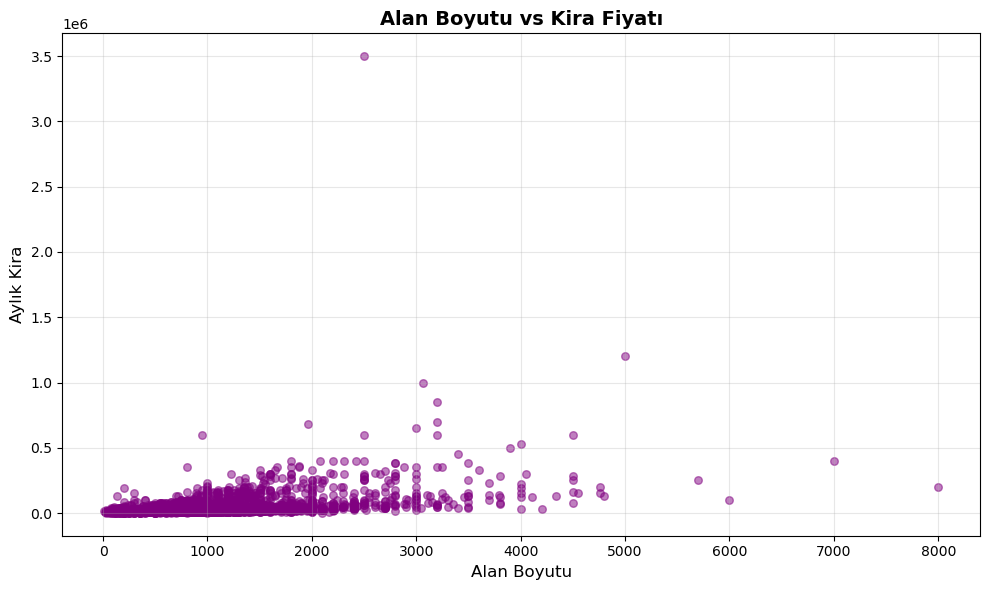

In [12]:
#Kira vs Alan Boyutu (Scatter Plot)
plt.figure(figsize=(10, 6))
plt.scatter(df['Size'], df['Rent'], alpha=0.5, color='purple', s=30)
plt.title('Alan Boyutu vs Kira Fiyatı', fontsize=14, fontweight='bold')
plt.xlabel('Alan Boyutu', fontsize=12)
plt.ylabel('Aylık Kira', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

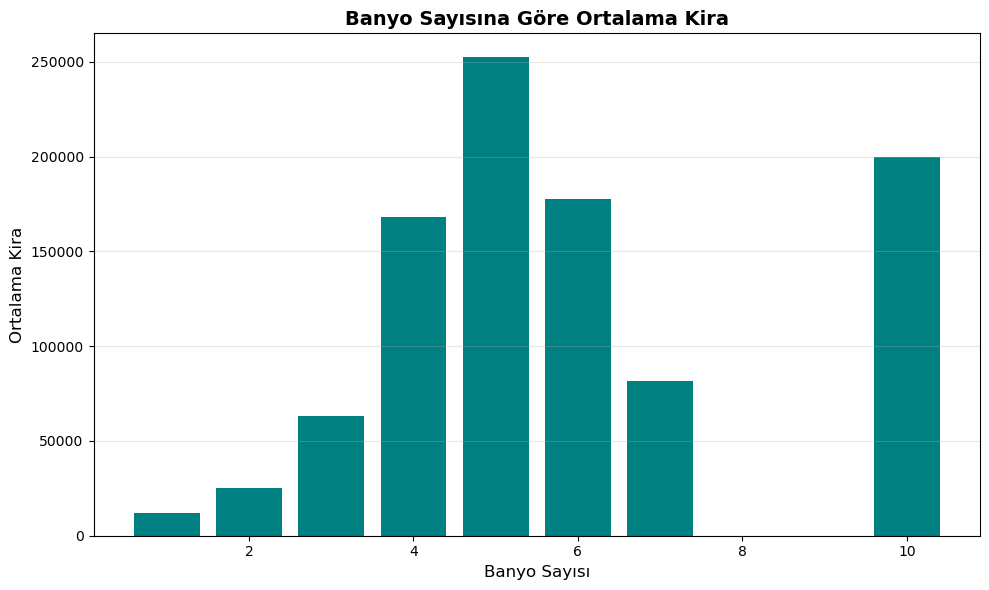

In [13]:
# Banyo sayısına göre ortalama kira
plt.figure(figsize=(10, 6))
bathroom_rent = df.groupby('Bathroom')['Rent'].mean().sort_index()
plt.bar(bathroom_rent.index, bathroom_rent.values, color='teal')
plt.title('Banyo Sayısına Göre Ortalama Kira', fontsize=14, fontweight='bold')
plt.xlabel('Banyo Sayısı', fontsize=12)
plt.ylabel('Ortalama Kira', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

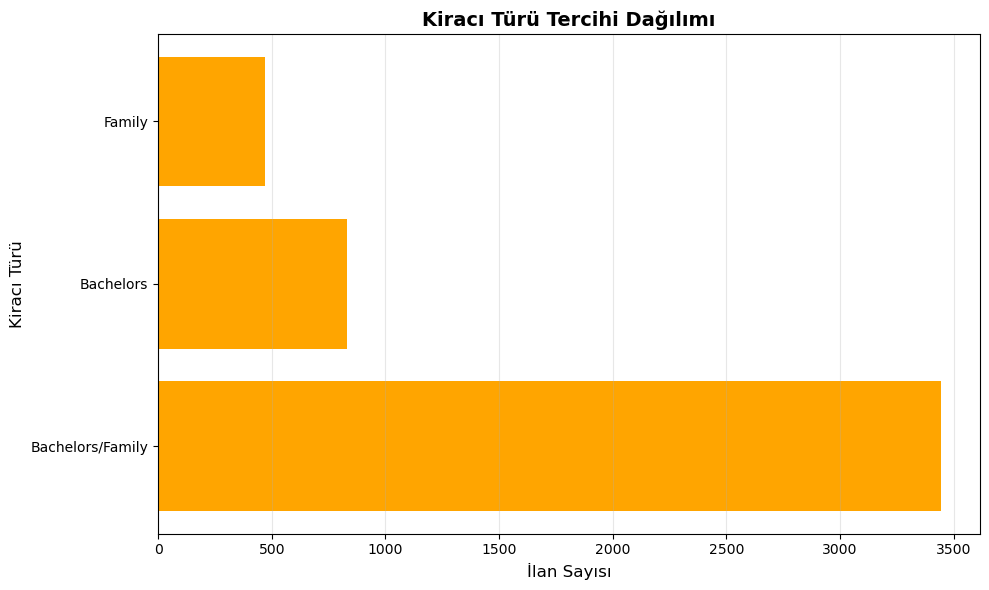

In [14]:
# Kiracı tercihi dağılımı
plt.figure(figsize=(10, 6))
tenant_count = df['Tenant Preferred'].value_counts()
plt.barh(tenant_count.index, tenant_count.values, color='orange')
plt.title('Kiracı Türü Tercihi Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('İlan Sayısı', fontsize=12)
plt.ylabel('Kiracı Türü', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
#Feature Engineering

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Posted On          4746 non-null   datetime64[ns]
 1   BHK                4746 non-null   int64         
 2   Rent               4746 non-null   int64         
 3   Size               4746 non-null   int64         
 4   Floor              4746 non-null   object        
 5   Area Type          4746 non-null   object        
 6   Area Locality      4746 non-null   object        
 7   City               4746 non-null   object        
 8   Furnishing Status  4746 non-null   object        
 9   Tenant Preferred   4746 non-null   object        
 10  Bathroom           4746 non-null   int64         
 11  Point of Contact   4746 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(7)
memory usage: 445.1+ KB


In [17]:
df['Posted On'].value_counts()

Posted On
2022-07-06    311
2022-05-12    149
2022-06-04    135
2022-07-09    126
2022-05-27    125
             ... 
2022-04-25      6
2022-04-24      6
2022-04-26      2
2022-04-13      1
2022-07-11      1
Name: count, Length: 81, dtype: int64

In [18]:
# Tarih kolonunu datetime'a dönüştürelim
df['Posted On'] = pd.to_datetime(df['Posted On'])

# 2. Posted On'dan yıl, ay ve hafta bilgilerini çıakrtalım
df['Posted_Year'] = df['Posted On'].dt.year
df['Posted_Month'] = df['Posted On'].dt.month
df['Posted_DayOfWeek'] = df['Posted On'].dt.dayofweek

In [19]:
# İlan Tarihi
current_date = pd.to_datetime('2026-03-23')  # Güncel tarih yazalım
df['Days_Since_Posted'] = (current_date - df['Posted On']).dt.days

In [20]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Posted_Year,Posted_Month,Posted_DayOfWeek,Days_Since_Posted
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,2022,5,2,1405
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,2022,5,4,1410
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,2022,5,0,1407
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,2022,7,0,1358
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,2022,5,0,1414


In [21]:
# Kira başına alan oranı
df['Price_Per_Sqft'] = df['Rent'] / df['Size']

In [22]:
df['Area Type'].value_counts()

Area Type
Super Area     2446
Carpet Area    2298
Built Area        2
Name: count, dtype: int64

In [23]:
df = df[df['Area Type'] != 'Built Area'].reset_index(drop=True)

In [24]:
# Kategorik değişkenleri numeric'e dönüştürelim
furnishing_mapping = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}
tenant_mapping = {'Bachelors': 0, 'Family': 1, 'Bachelors/Family': 2}
area_mapping = {'Carpet Area': 0, 'Super Area': 1}

df['Furnishing'] = df['Furnishing Status'].map(furnishing_mapping).astype('Int64')
df['Tenant'] = df['Tenant Preferred'].map(tenant_mapping).astype('Int64')
df['Area_Type'] = df['Area Type'].map(area_mapping).astype('Int64')

In [25]:
df.describe()

,Posted On,BHK,Rent,Size,Bathroom,Posted_Year,Posted_Month,Posted_DayOfWeek,Days_Since_Posted,Price_Per_Sqft,Furnishing,Tenant,Area_Type
count,4744,4744.000000,4.744000e+03,4744.000000,4744.000000,4744.0,4744.000000,4744.000000,4744.000000,4744.000000,4744.0,4744.0,4744.0
mean,2022-06-07 17:54:50.387858432,2.084106,3.500378e+04,967.582420,1.966062,2022.0,5.755691,2.928331,1384.253583,39.267946,0.76075,1.55059,0.515599
min,2022-04-13 00:00:00,1.000000,1.200000e+03,10.000000,1.000000,2022.0,4.000000,0.000000,1351.000000,0.571429,0.0,0.0,0.0
25%,2022-05-20 00:00:00,2.000000,1.000000e+04,550.000000,1.000000,2022.0,5.000000,2.000000,1364.000000,13.333333,0.0,1.0,0.0
50%,2022-06-10 00:00:00,2.000000,1.600000e+04,850.000000,2.000000,2022.0,6.000000,3.000000,1382.000000,20.000000,1.0,2.0,1.0
75%,2022-06-28 00:00:00,3.000000,3.300000e+04,1200.000000,2.000000,2022.0,6.000000,4.000000,1403.000000,42.032302,1.0,2.0,1.0
max,2022-07-11 00:00:00,6.000000,3.500000e+06,8000.000000,10.000000,2022.0,7.000000,6.000000,1440.000000,1500.000000,2.0,2.0,1.0
std,NaN,0.832282,7.812120e+04,634.299524,0.884607,0.0,0.832586,1.832061,22.052034,59.865503,0.684371,0.77297,0.499809


In [26]:
# Floor numarası çıkaralım
def extract_floor_number(floor_str):
    try:
        return int(floor_str.split()[0])
    except:
        return 0

df['Floor_Number'] = df['Floor'].apply(extract_floor_number)

In [27]:
#Zemin kat mı değil mi,
df['Is_Ground_Floor'] = (df['Floor_Number'] == 0).astype(int)

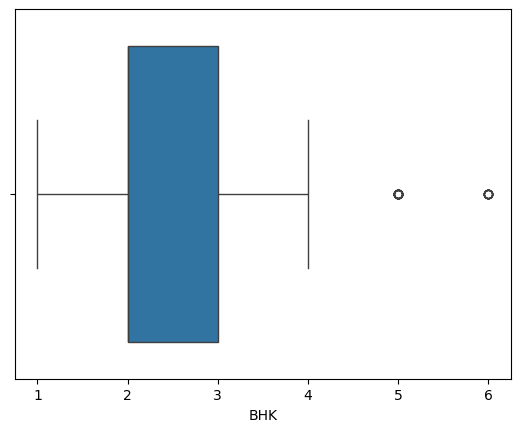

In [28]:
sns.boxplot(x=df['BHK']);

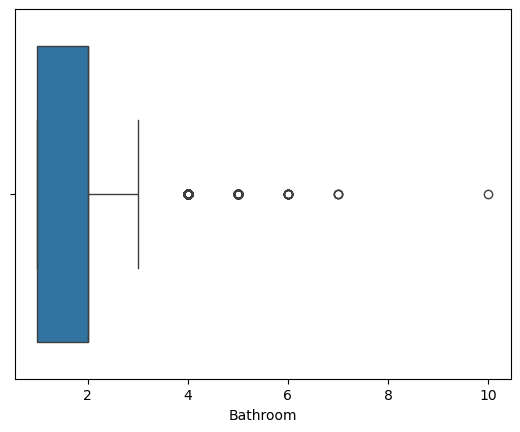

In [29]:
sns.boxplot(x=df['Bathroom']);  

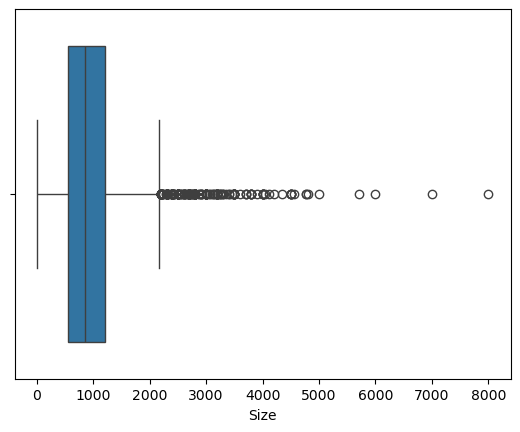

In [30]:
sns.boxplot(x=df['Size']);  

In [31]:
df['BHK'].mean()+3*df['BHK'].std()
df['Size'].mean()+3*df['Size'].std()
df['Bathroom'].mean()+3*df['Bathroom'].std()

np.float64(4.61988282838328)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4744 entries, 0 to 4743
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Posted On          4744 non-null   datetime64[ns]
 1   BHK                4744 non-null   int64         
 2   Rent               4744 non-null   int64         
 3   Size               4744 non-null   int64         
 4   Floor              4744 non-null   object        
 5   Area Type          4744 non-null   object        
 6   Area Locality      4744 non-null   object        
 7   City               4744 non-null   object        
 8   Furnishing Status  4744 non-null   object        
 9   Tenant Preferred   4744 non-null   object        
 10  Bathroom           4744 non-null   int64         
 11  Point of Contact   4744 non-null   object        
 12  Posted_Year        4744 non-null   int32         
 13  Posted_Month       4744 non-null   int32         
 14  Posted_D

In [33]:
#Correlation by Salary
abs(df.corr(numeric_only=True))['Rent'].sort_values(ascending=False)

Rent                 1.000000
Price_Per_Sqft       0.551543
Bathroom             0.441197
Size                 0.413528
BHK                  0.369685
Floor_Number         0.327100
Area_Type            0.215688
Furnishing           0.146335
Days_Since_Posted    0.107622
Is_Ground_Floor      0.106588
Posted_Month         0.101968
Tenant               0.066130
Posted_DayOfWeek     0.008973
Posted_Year               NaN
Name: Rent, dtype: float64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4744 entries, 0 to 4743
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Posted On          4744 non-null   datetime64[ns]
 1   BHK                4744 non-null   int64         
 2   Rent               4744 non-null   int64         
 3   Size               4744 non-null   int64         
 4   Floor              4744 non-null   object        
 5   Area Type          4744 non-null   object        
 6   Area Locality      4744 non-null   object        
 7   City               4744 non-null   object        
 8   Furnishing Status  4744 non-null   object        
 9   Tenant Preferred   4744 non-null   object        
 10  Bathroom           4744 non-null   int64         
 11  Point of Contact   4744 non-null   object        
 12  Posted_Year        4744 non-null   int32         
 13  Posted_Month       4744 non-null   int32         
 14  Posted_D

In [35]:
df['Area Locality'].value_counts()

Area Locality
Bandra West                              37
Gachibowli                               29
Electronic City                          24
Velachery                                22
Miyapur, NH 9                            22
                                         ..
Kakatiya Hills Madhapur                   1
sanath nagar Ashok colony                 1
Mokila                                    1
Neknampur, Manikonda, Outer Ring Road     1
Naseeb Nagar, Hyderabad                   1
Name: count, Length: 2234, dtype: int64

In [36]:
# En sık 10 yerleşimi seç
top_localities = df['Area Locality'].value_counts().head(10).index
df['Area_Locality_Top10'] = df['Area Locality'].apply(lambda x: x if x in top_localities else 'Other')

In [37]:
df['Area_Locality_Top10'].value_counts()

Area_Locality_Top10
Other              4515
Bandra West          37
Gachibowli           29
Electronic City      24
Miyapur, NH 9        22
Velachery            22
Madipakkam           20
Chembur              19
K R Puram            19
Laxmi Nagar          19
Kondapur             18
Name: count, dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4744 entries, 0 to 4743
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Posted On            4744 non-null   datetime64[ns]
 1   BHK                  4744 non-null   int64         
 2   Rent                 4744 non-null   int64         
 3   Size                 4744 non-null   int64         
 4   Floor                4744 non-null   object        
 5   Area Type            4744 non-null   object        
 6   Area Locality        4744 non-null   object        
 7   City                 4744 non-null   object        
 8   Furnishing Status    4744 non-null   object        
 9   Tenant Preferred     4744 non-null   object        
 10  Bathroom             4744 non-null   int64         
 11  Point of Contact     4744 non-null   object        
 12  Posted_Year          4744 non-null   int32         
 13  Posted_Month         4744 non-nul

In [39]:
df['Point of Contact'].value_counts()

Point of Contact
Contact Owner      3214
Contact Agent      1529
Contact Builder       1
Name: count, dtype: int64

In [40]:
df = df[df['Point of Contact'] != 'Contact Builder']

In [41]:
#Correlation by Salary
abs(df.corr(numeric_only=True))['Rent'].sort_values(ascending=False)

Rent                 1.000000
Price_Per_Sqft       0.551528
Bathroom             0.441172
Size                 0.413498
BHK                  0.369653
Floor_Number         0.327077
Area_Type            0.215636
Furnishing           0.146267
Days_Since_Posted    0.107663
Is_Ground_Floor      0.106633
Posted_Month         0.101994
Tenant               0.066087
Posted_DayOfWeek     0.008884
Posted_Year               NaN
Name: Rent, dtype: float64

In [42]:
cols = [
    'BHK',
    'Size',
    'Bathroom',
    'Price_Per_Sqft',
    'Floor_Number',
    'Days_Since_Posted',
    'Posted_Month',
    'Area_Type',
    'Furnishing',
    'Tenant',
    'Is_Ground_Floor',
    'City',
    'Point of Contact',
    'Area_Locality_Top10'
]

# x ve y
x = df[cols]
y = df[['Rent']] 

In [43]:
x.head()

,BHK,Size,Bathroom,Price_Per_Sqft,Floor_Number,Days_Since_Posted,Posted_Month,Area_Type,Furnishing,Tenant,Is_Ground_Floor,City,Point of Contact,Area_Locality_Top10
0,2,1100,2,9.090909,0,1405,5,1,0,2,1,Kolkata,Contact Owner,Other
1,2,800,1,25.000000,1,1410,5,1,1,2,0,Kolkata,Contact Owner,Other
2,2,1000,1,17.000000,1,1407,5,1,1,2,0,Kolkata,Contact Owner,Other
3,2,800,1,12.500000,1,1358,7,1,0,2,0,Kolkata,Contact Owner,Other
4,2,850,1,8.823529,1,1414,5,0,0,0,0,Kolkata,Contact Owner,Other


In [44]:
x=pd.get_dummies(x, drop_first=True)

In [45]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [46]:
lr=LinearRegression()

In [47]:
model=lr.fit(x_train, y_train)

In [48]:
tahmin=lr.predict(x_test)

In [49]:
r2_score(y_test,tahmin)

0.6134158661186448

In [50]:
mean_squared_error(y_test,tahmin)**0.5

40231.762031784696

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
       
        
        algos=[L,R,Lass,E,ETR,GBR,kn,dt,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting','KNeighborsRegressor','Decision Tree','XGBRegressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [52]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.929837,17139.564522,2629.447266
Gradient Boosting,0.922621,17999.389112,4165.295725
Decision Tree,0.874910,22885.353558,3401.858799
Extra Tree,0.857054,24464.278253,5709.443625
KNeighborsRegressor,0.699644,35462.190262,6466.333404
Linear,0.613416,40231.762032,18844.347776
Lasso,0.613266,40239.558932,18855.537341
Ridge,0.612592,40274.603938,18908.632596
ElasticNet,0.589794,41442.684816,17959.271045


In [53]:
comparison = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Predicted': tahmin.ravel()
})

comparison.sample(5)

,Actual,Predicted
924,15000,8811.071085
889,100000,100765.431121
529,8500,2168.329196
223,34999,54268.507764
240,36000,50802.138182


In [54]:
residuals=y_test-tahmin

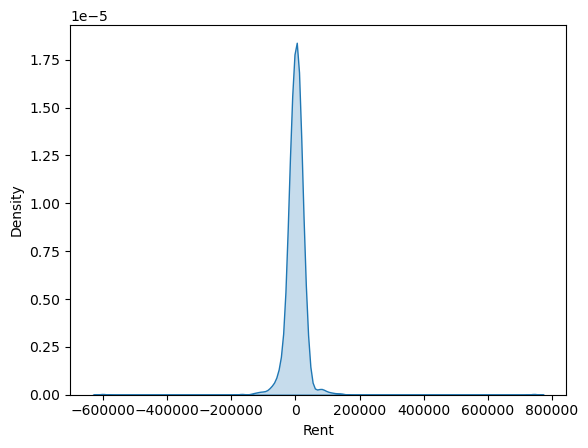

In [55]:
sns.kdeplot(x=residuals['Rent'], fill=True); 

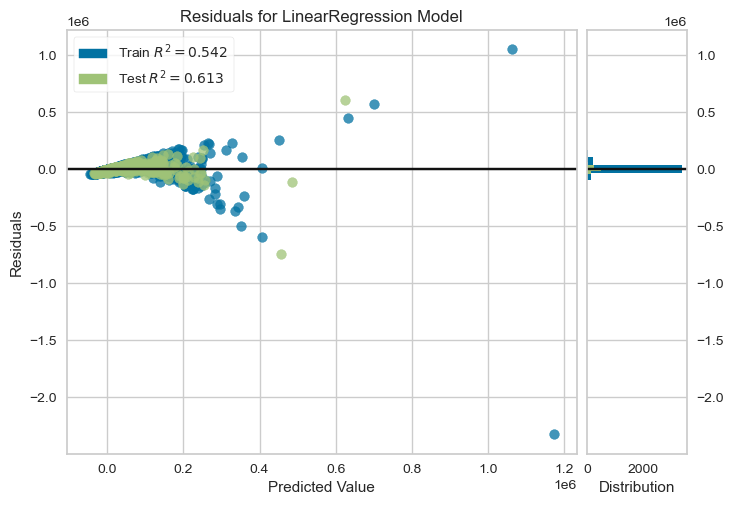

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [56]:
from yellowbrick.regressor import ResidualsPlot
vis = ResidualsPlot(model, force_model=True)
vis.fit(x_train, y_train)
vis.score(x_test, y_test)
vis.show()

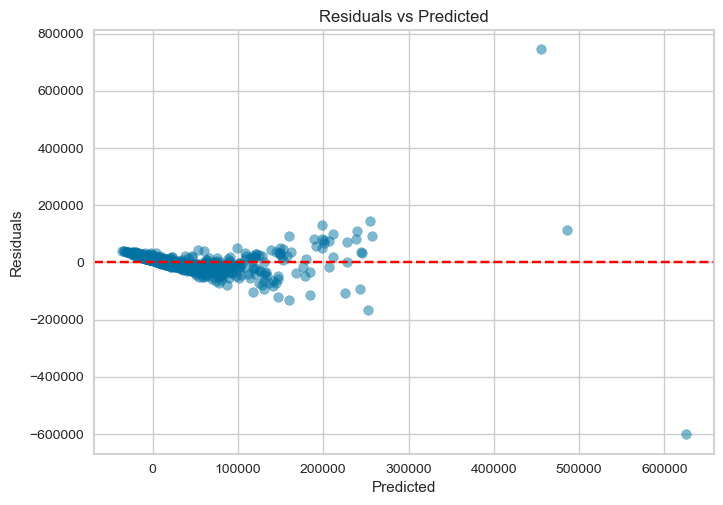

In [57]:
#ya da;
y_pred = model.predict(x_test)
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

In [58]:
from xgboost import XGBRegressor
best_model = XGBRegressor()
best_model.fit(x, y)

#2. Feature listesini al
features = list(x.columns)

# 3. Modeli kaydet (joblib + pkl)
import joblib, pickle

# joblib 
joblib.dump(best_model, 'house_rent.joblib')

# bundle (model + feature)
with open('house_rent.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'features': features
    }, f)

In [59]:
# with DEEP LEarnıng

In [61]:
x.head()

,BHK,Size,Bathroom,Price_Per_Sqft,Floor_Number,Days_Since_Posted,Posted_Month,Area_Type,Furnishing,Tenant,Is_Ground_Floor,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Point of Contact_Contact Owner,Area_Locality_Top10_Chembur,Area_Locality_Top10_Electronic City,Area_Locality_Top10_Gachibowli,Area_Locality_Top10_K R Puram,Area_Locality_Top10_Kondapur,Area_Locality_Top10_Laxmi Nagar,Area_Locality_Top10_Madipakkam,"Area_Locality_Top10_Miyapur, NH 9",Area_Locality_Top10_Other,Area_Locality_Top10_Velachery
0,2,1100,2,9.090909,0,1405,5,1,0,2,1,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False
1,2,800,1,25.000000,1,1410,5,1,1,2,0,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False
2,2,1000,1,17.000000,1,1407,5,1,1,2,0,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False
3,2,800,1,12.500000,1,1358,7,1,0,2,0,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False
4,2,850,1,8.823529,1,1414,5,0,0,0,0,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False


In [62]:
y

,Rent
0,10000
1,20000
2,17000
3,10000
4,7500
...,...
4739,15000
4740,29000
4741,35000
4742,45000


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x=scaler.fit_transform(x)

In [64]:
model=Sequential()
model.add(Dense(80, activation='relu'))           
model.add(Dense(120, activation='relu'))  
model.add(Dense(64, activation='relu'))  
model.add(Dense(30, activation='relu'))  
model.add(Dense(8, activation='relu'))  
model.add(Dense(1))  #sigmoid yok  classificaton binary idi. 

model.compile(loss='mean_squared_error', optimizer='adam')

In [65]:
early_stop=EarlyStopping(monitor='val_loss',patience=20)

In [66]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50,batch_size=64,callbacks=[early_stop],verbose=1)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 7370603008.0000 - val_loss: 3748330496.0000
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5903289856.0000 - val_loss: 3369180160.0000
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5595021312.0000 - val_loss: 3108867840.0000
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5414009344.0000 - val_loss: 2935566080.0000
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5281217536.0000 - val_loss: 2821015296.0000
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5107292672.0000 - val_loss: 2686779392.0000
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4941315584.0000 - val_loss: 2548604672.0000
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4756470272.0000 - val_loss: 2332329984.0000
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4453454336.0000 - val_loss: 2097783168.0000
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4056223232.0000 - val_

In [67]:
tahmin = model.predict(x_test).flatten()

print("R2:", r2_score(y_test, tahmin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tahmin)))

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
R2: 0.9537516832351685
RMSE: 13915.379118083703


In [68]:
comparison = pd.DataFrame({
    "Gerçek Fiyat": y_test.to_numpy().ravel(),
    "Tahmin Fiyat": tahmin.ravel()
})

comparison.head(10)

,Gerçek Fiyat,Tahmin Fiyat
0,70000,68208.304688
1,8000,6266.822266
2,9500,8750.249023
3,5500,2900.848877
4,7000,5411.062500
5,35000,35816.179688
6,6500,5373.708008
7,80000,85974.460938
8,28000,23577.187500
9,12000,7588.610840


In [69]:
model.save('rent_model.h5')

🇹🇷 Türkçe
Bu çalışmada, kira fiyatlarını tahmin etmek amacıyla farklı makine öğrenmesi regresyon modelleri kullanılmıştır. Veri ön işleme ve modelleme süreçlerinin ardından modeller performans metrikleri ile karşılaştırılmıştır. Sonuçlara göre makine öğrenmesi algoritmalarından XGBRegressor modeli en yüksek başarıyı (R² ≈ 0.92) elde ederek en düşük hata oranlarıyla en iyi tahmin performansını göstermiştir. Derin öğrenme ile 0.95 R² oranı elde edilmiştir.

🇬🇧 English
In this study, various machine learning regression models were used to predict house rent prices. After data preprocessing and modeling steps, the models were evaluated and compared using performance metrics. According to the results, the XGBRegressor model among machine learning algorithms achieved the highest success rate (R² ≈ 0.92), demonstrating the best prediction performance with the lowest error rates. An R² ratio of 0.95 was obtained with deep learning.